# eQTL benchmark 5 — the Borzoi retrain panel

`eQTL_benchmark4` compared Enformer / Borzoi / Mamba / AlphaGenome on the EPCOTv2 LCL
eQTL set. This notebook keeps that machinery and swaps the arm list for the question
`comparing_model5` was really asking: **does finetuning Borzoi on GM12878 buy you
anything on variant effect prediction?**

Nine arms, four families:

| family | arms |
|---|---|
| Enformer | pretrained |
| Mamba | GM12878, 8 immune cell types |
| Borzoi | pretrained, LoRA v2, full FT (trunk), from scratch |
| Caduceus→Borzoi-32bp | ep4, ep10 |

Dropped from `eQTL_benchmark4`: `nopretrain`, both AlphaGenome arms, and the
`transformer` / `striped` arrays.

> **One thing to check before you trust §4.** You asked for this "without enformer …"
> but then listed enformer in the keep set. I kept it, because the second list was the
> explicit one. To drop it, delete the one `Arm('enformer', …)` line in §1 — everything
> downstream is driven off `ARMS` and will follow.

Everything is self-contained and gated: §1 refuses to continue if the arrays disagree
about window geometry, sample order, or scorability. No `if ... not in globals()`
guards, so the notebook runs top-to-bottom on a cold kernel.

## 1. Arms, load, and the gate

The one number that matters here is the **comparison window**. `eQTL_benchmark4` wrote it
as a per-arm magic constant (`center = [16, 16*4, 16, 16, 16, 16*128]`), which is easy to
get wrong when adding an arm. Those constants are all the same physical span:

    Enformer / Mamba   128 bp bins x  16 bins = 2048 bp
    Borzoi / Caduceus   32 bp bins x  64 bins = 2048 bp
    AlphaGenome (nb4)    1 bp bins x 2048     = 2048 bp

(Mamba's resolution is not an assumption: its `EnformerDecoder` is built with the
default `yshape=114688, bin_size=128`, giving the 896 bins the array carries.)

So this notebook stores `bin_bp` per arm and *derives* the window, then asserts every arm
really does land on 2048 bp. Adding an arm means stating its bin size, not recomputing a
magic number.

The gate also checks the thing that actually bit us: an arm is only scorable where its
output span reaches the variant. Rows outside it are all-zero, and
`predict_snp_effect_scores` maps those to a score of 0.0 — which silently ranks them
*last* rather than excluding them. §5 deals with the consequences.

In [1]:
# §1 - arms, load, and the gate.
import json
import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import auc, precision_recall_curve

QTL_DIR = '/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/'
CENTER_BP = 2048          # physical width of the comparison window, every arm
N_QTL = 1331

# Distance bins, verbatim from eQTL_benchmark4.
THRESHOLDS = [1_000, 10_000, 524_288 // 2]
BIN_NAMES = ['<1 kb (proximal)', '1-10 kb (flanking)', '10-262 kb (distal)']


@dataclass
class Arm:
    key: str
    fname: str
    bin_bp: int          # bp per output bin -> the 2048 bp window is derived, not hardcoded
    input_bp: int        # sequence the eval script fed the model -> sets which variants exist at all
    label: str
    family: str
    color: str


# Colours: hue = family, lightness = position within family. Validated with the dataviz
# palette checker (light mode): the four family hues pass all-pairs CVD separation
# (worst dE 13.0) and each family ramp passes the ordinal checks. Identity never rests on
# colour alone -- every bar is named on the y axis and carries its value.
ARMS = [
    Arm('enformer',    'enformer_eqtl.npy',       128, 196_608, 'Enformer (~800 cell types)',  'Enformer', '#2a78d6'),
    Arm('mamba_gm',    'nomlm_maskonly.npy',      128, 524_288, 'Mamba (GM12878)',             'Mamba',    '#e87ba4'),
    Arm('mamba_imm',   'immune.npy',              128, 524_288, 'Mamba (8 immune cell types)', 'Mamba',    '#b23a68'),
    Arm('borzoi_pre',  'borzoi_eqtl.npy',          32, 524_288, 'Borzoi (pretrained)',         'Borzoi',   '#a89ae0'),
    Arm('borzoi_lora', 'borzoi_eqtl_lorav2.npy',   32, 524_288, 'Borzoi LoRA v2',              'Borzoi',   '#7c66c4'),
    Arm('borzoi_trunk','borzoi_eqtl_trunk.npy',    32, 524_288, 'Borzoi full FT (trunk)',      'Borzoi',   '#4a3aa7'),
    Arm('borzoi_scr',  'borzoi_eqtl_scratch.npy',  32, 524_288, 'Borzoi from scratch',         'Borzoi',   '#2b1f6b'),
    Arm('cad_ep4',     'borzoi32_ep4.npy',         32, 524_288, 'Caduceus ep4',                'Caduceus', '#5fb763'),
    Arm('cad_ep10',    'borzoi32_ep10.npy',        32, 524_288, 'Caduceus ep10',               'Caduceus', '#008300'),
]
KEYS = [a.key for a in ARMS]
ARM = {a.key: a for a in ARMS}

# --- eQTLs, labels, TSS distances ------------------------------------------------
qtls = pd.read_csv(QTL_DIR + 'LCLs.txt', sep=' ', header=None)
qtls.columns = ['label', 'qtl_idx', 'gene_idx', 'chrom', 'gene_start', 'gene_end',
                'strand', 'qtl_loc', 'ref', 'alt', 'sign_target']
labels = qtls['label'].to_numpy()
assert len(qtls) == N_QTL, f'{len(qtls)} eQTLs, expected {N_QTL}'
assert set(np.unique(labels)) <= {0, 1}, 'labels are not 0/1'

with open(QTL_DIR + 'genes.pickle', 'rb') as f:
    gene_annotation = pickle.load(f)
ordered_genes = sorted(list(gene_annotation.keys()))

tmpgeneTSS = np.loadtxt(QTL_DIR + 'ensemblTSS.txt', dtype='str')
geneTSS_dic = {tmpgeneTSS[i, 0]: int(tmpgeneTSS[i, 1]) for i in range(tmpgeneTSS.shape[0])}

distances = np.zeros((len(qtls),), dtype=int)
for i in range(len(qtls)):
    temp = qtls.iloc[i]
    pos = temp['qtl_loc'] - 1
    tss_loc = geneTSS_dic[ordered_genes[temp['gene_idx']]]
    distances[i] = abs(tss_loc - pos)

DIST_MASKS = [
    distances < THRESHOLDS[0],
    (distances >= THRESHOLDS[0]) & (distances < THRESHOLDS[1]),
    (distances >= THRESHOLDS[1]) & (distances < THRESHOLDS[2]),
]
print(f'{len(qtls)} eQTLs, {labels.sum()} positive ({labels.mean():.1%})')
for nm, m in zip(BIN_NAMES, DIST_MASKS):
    print(f'  {nm:<20} n={m.sum():>4}  positives={int(labels[m].sum()):>4} '
          f'({labels[m].mean():.1%} -- this is the chance AUPRC for that bin)')

# --- load, slice to the common 2048 bp window ------------------------------------
missing = [a.fname for a in ARMS if not os.path.exists(QTL_DIR + a.fname)]
assert not missing, 'prediction files not on disk:\n  ' + '\n  '.join(missing)

WIN = {}        # key -> (N_QTL, n_bins_in_window, 2)
SCORABLE = {}   # key -> bool mask, True where the arm actually produced a prediction
print(f'\n{"arm":<30}{"bins":>7}{"bp/bin":>8}{"window":>10}{"scorable":>10}')
for a in ARMS:
    full = np.asarray(np.load(QTL_DIR + a.fname, mmap_mode='r'), dtype=np.float64)
    assert full.shape[0] == N_QTL and full.shape[2] == 2, f'{a.key}: shape {full.shape}'

    n_bins = CENTER_BP // a.bin_bp
    assert n_bins * a.bin_bp == CENTER_BP, f'{a.key}: {a.bin_bp} bp bins do not tile {CENTER_BP} bp'
    cs = full.shape[1] // 2 - n_bins // 2
    w = full[:, cs:cs + n_bins, :]

    WIN[a.key] = w
    SCORABLE[a.key] = full.sum(axis=(1, 2)) != 0
    # the window must agree with the full array about which rows exist at all, or the
    # zero-masking in predict_snp_effect_scores means something different per arm
    assert np.array_equal(SCORABLE[a.key], w.sum(axis=(1, 2)) != 0), (
        f'GATE FAILED: {a.key} has rows that are zero in the window but not in the full array')
    print(f'{a.label:<30}{full.shape[1]:>7}{a.bin_bp:>8}{str(n_bins) + " bins":>10}'
          f'{SCORABLE[a.key].sum():>10}')

# ============================== GATE ==============================
# 1. every arm covers exactly the same physical span
spans = {a.key: WIN[a.key].shape[1] * a.bin_bp for a in ARMS}
assert set(spans.values()) == {CENTER_BP}, f'GATE FAILED: windows disagree: {spans}'
print(f'\ngate 1: all {len(ARMS)} arms compared over the same {CENTER_BP} bp centred window')

# 2. log() is safe -- predict_snp_effect_scores takes log of both arms
for a in ARMS:
    v = WIN[a.key][SCORABLE[a.key]]
    assert np.isfinite(v).all(), f'GATE FAILED: {a.key} has non-finite predictions'
    assert (v > 0).all(), (f'GATE FAILED: {a.key} has a non-positive value inside the window '
                           f'(min {v.min():.3e}) -- np.log would produce -inf')
print(f'gate 2: all arms strictly positive inside the window; log-based metrics are safe')

# 3. no arm is a copy of another
for i, ka in enumerate(KEYS):
    for kb in KEYS[i + 1:]:
        if WIN[ka].shape == WIN[kb].shape:
            assert not np.array_equal(WIN[ka], WIN[kb]), f'GATE FAILED: {ka} and {kb} are identical'
print(f'gate 3: all {len(ARMS)} arms are distinct')

# 4. the variant actually changed the prediction, everywhere it was scored
for a in ARMS:
    w = WIN[a.key][SCORABLE[a.key]]
    n_flat = int((w[:, :, 0] == w[:, :, 1]).all(axis=1).sum())
    assert n_flat == 0, f'GATE FAILED: {a.key} has {n_flat} scored rows where ref == alt exactly'
print('gate 4: every scored row has ref != alt in all arms')

# 5. the declared input window must be the one the arrays actually show.
#    A row is non-zero iff the eval script placed the variant inside the model's input
#    sequence, i.e. iff |TSS - variant| < input_bp/2. This is the real support limit --
#    NOT the output span. Deriving it from the data means input_bp cannot silently rot.
for a in ARMS:
    half = a.input_bp // 2
    s_, u_ = SCORABLE[a.key], ~SCORABLE[a.key]
    assert distances[s_].max() < half, (
        f'GATE FAILED: {a.key} scored a variant {distances[s_].max():,} bp from the TSS but '
        f'its input window only reaches {half:,} bp')
    assert u_.sum() == 0 or distances[u_].min() >= half, (
        f'GATE FAILED: {a.key} left a variant at {distances[u_].min():,} bp unscored, inside '
        f'its {half:,} bp reach')
print('gate 5: every arm\'s non-zero rows match its declared input window exactly')

# 6. scorability is nested, so "common support" is just the narrowest arm
base = SCORABLE[max(KEYS, key=lambda k: SCORABLE[k].sum())]
for a in ARMS:
    assert (SCORABLE[a.key] <= base).all(), f'GATE FAILED: {a.key} scores a row no other arm does'
COMMON = np.logical_and.reduce([SCORABLE[k] for k in KEYS])
print(f'gate 6: scorability is nested; {COMMON.sum()} / {N_QTL} rows are scorable by every arm')
print('\nGATE PASSED.')

1331 eQTLs, 232 positive (17.4%)
  <1 kb (proximal)     n= 291  positives= 123 (42.3% -- this is the chance AUPRC for that bin)
  1-10 kb (flanking)   n= 146  positives=  35 (24.0% -- this is the chance AUPRC for that bin)
  10-262 kb (distal)   n= 830  positives=  70 (8.4% -- this is the chance AUPRC for that bin)

arm                              bins  bp/bin    window  scorable
Enformer (~800 cell types)        896     128   16 bins      1023
Mamba (GM12878)                   896     128   16 bins      1267
Mamba (8 immune cell types)       896     128   16 bins      1267
Borzoi (pretrained)              6144      32   64 bins      1267
Borzoi LoRA v2                   6144      32   64 bins      1267
Borzoi full FT (trunk)           6144      32   64 bins      1267
Borzoi from scratch              6144      32   64 bins      1267
Caduceus ep4                     6144      32   64 bins      1267
Caduceus ep10                    6144      32   64 bins      1267

gate 1: all 9 arms co

## 2. The effect-size metrics

Verbatim from `eQTL_benchmark4` so the numbers stay comparable. `logfc` (index 0) is the
metric every figure below uses, matching nb4.

Note the zero-row behaviour: a variant an arm could not score gets `0.0`, not `nan`. Under
`np.abs(...)` that is the *smallest possible* score, so those rows are ranked last rather
than dropped. That is fine when every arm has the same support and actively misleading
when they do not — which is exactly the Enformer situation in §5.

In [2]:
# §2 - metrics, verbatim from eQTL_benchmark4.
def predict_snp_effect_scores(ref_prob_preds, alt_prob_preds):
    """
    ref_prob_preds, alt_prob_preds: arrays of shape (N, L)
    returns five length-N arrays, with zeros for any row where both inputs are all-zero.
    """
    # 1) mask out rows where both ref & alt are entirely zero
    zero_mask = (ref_prob_preds.sum(axis=1) == 0) & (alt_prob_preds.sum(axis=1) == 0)
    valid    = ~zero_mask
    N        = ref_prob_preds.shape[0]

    # 2) prepare empty outputs
    logfc                    = np.zeros(N, dtype=float)
    log_probs_diff_abs_sum   = np.zeros(N, dtype=float)
    probs_jsd_diff           = np.zeros(N, dtype=float)
    integrative_effect_size  = np.zeros(N, dtype=float)
    integrative_effect_size2 = np.zeros(N, dtype=float)

    # 3) only compute on the valid rows
    if np.any(valid):
        r = ref_prob_preds[valid]
        a = alt_prob_preds[valid]

        lpd = np.sum(np.abs(np.log(a) - np.log(r)), axis=1)
        jsd = np.array([jensenshannon(x, y) for x, y in zip(a, r)])
        lf  = np.log2(r.mean(axis=1) / a.mean(axis=1))
        ies  = lf * jsd
        ies2 = lpd * jsd

        log_probs_diff_abs_sum[valid]   = lpd
        probs_jsd_diff[valid]           = jsd
        logfc[valid]                    = lf
        integrative_effect_size[valid]  = ies
        integrative_effect_size2[valid] = ies2

    return logfc, log_probs_diff_abs_sum, probs_jsd_diff, \
           integrative_effect_size, integrative_effect_size2


METRIC_NAMES = ['logfc', 'log_probs_diff_abs_sum', 'JSD', 'IES1', 'IES2']
METRIC_IDX = 0        # logFC, as in eQTL_benchmark4

# score every arm once; all figures below read from here
SCORES = {}
for a in ARMS:
    out = predict_snp_effect_scores(WIN[a.key][:, :, 0], WIN[a.key][:, :, 1])
    SCORES[a.key] = {nm: np.abs(out[i]) for i, nm in enumerate(METRIC_NAMES)}
    assert np.isfinite(SCORES[a.key]['logfc']).all(), f'{a.key}: non-finite logfc'
print(f'scored {len(ARMS)} arms x {len(METRIC_NAMES)} metrics on {N_QTL} variants')

scored 9 arms x 5 metrics on 1331 variants


## 3. AUPRC by distance to TSS

The `eQTL_benchmark4` figure, re-cut for nine arms. Two changes to the form, both because
nine grouped bars across three bins is unreadable:

* **Small multiples instead of one grouped chart** — one panel per distance bin, bars
  sorted within the panel. The model name sits on the axis, so identity does not depend on
  telling nine colours apart.
* **A chance line.** AUPRC's baseline is the positive rate, and that differs a lot across
  these bins (42% proximal, 24% flanking, 8% distal). Without it the distal panel looks
  like universal failure when the models are in fact above chance.

Colour is family, lightness is position within family — so "did the Borzoi family move" is
readable at a glance, which is the actual question.

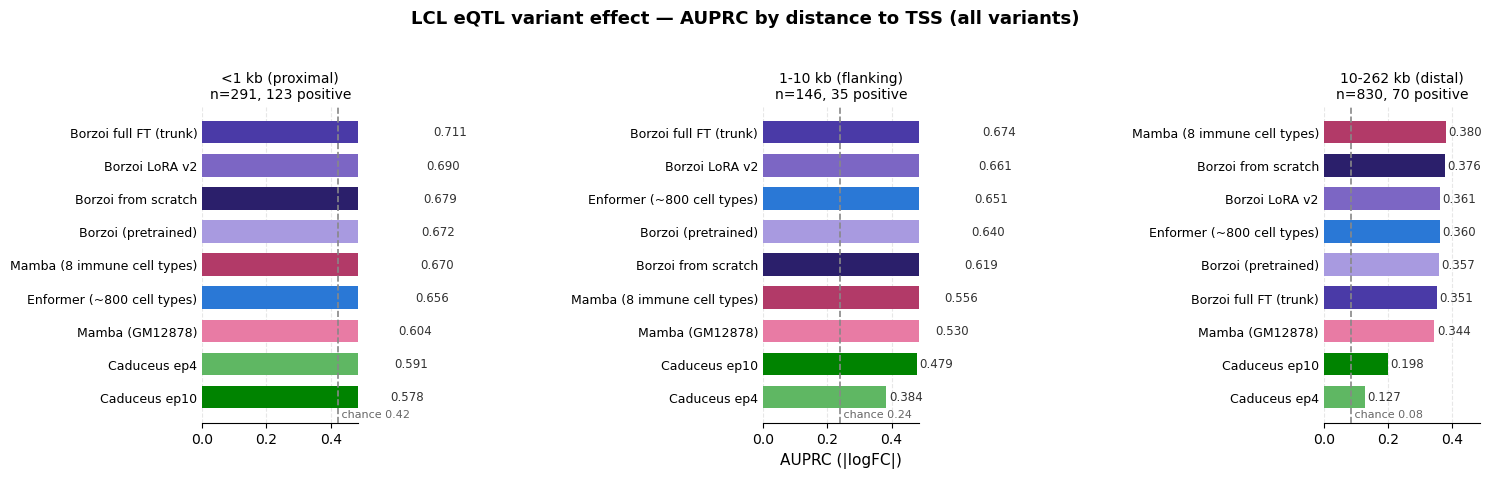

In [3]:
# §3 - AUPRC by distance bin.
def auprc_table(score_key='logfc', row_mask=None):
    """AUPRC per (distance bin, arm). row_mask further restricts every bin."""
    out = np.zeros((len(BIN_NAMES), len(ARMS)))
    for bi, dm in enumerate(DIST_MASKS):
        m = dm if row_mask is None else (dm & row_mask)
        for ai, a in enumerate(ARMS):
            pr, rc, _ = precision_recall_curve(labels[m], SCORES[a.key][score_key][m])
            out[bi, ai] = auc(rc, pr)
    return out


def plot_auprc_panels(auprc, title, row_mask=None, fname=None):
    n_used = DIST_MASKS if row_mask is None else [d & row_mask for d in DIST_MASKS]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True)
    for bi, ax in enumerate(axes):
        order = np.argsort(auprc[bi])[::-1]
        y = np.arange(len(ARMS))
        ax.barh(y, auprc[bi][order], height=0.68,
                color=[ARMS[i].color for i in order], zorder=3)
        ax.set_yticks(y)
        ax.set_yticklabels([ARMS[i].label for i in order], fontsize=9)
        ax.invert_yaxis()
        for yi, i in enumerate(order):
            ax.text(auprc[bi][i] + 0.008, yi, f'{auprc[bi][i]:.3f}',
                    va='center', ha='left', fontsize=8.5, color='#333333')
        chance = labels[n_used[bi]].mean()
        ax.axvline(chance, ls='--', lw=1.2, color='#888888', zorder=4)
        # x in data coords, y in axes fraction -> pinned to the bottom, never the title
        ax.text(chance, 0.01, f' chance {chance:.2f}', fontsize=8, color='#666666',
                ha='left', va='bottom', transform=ax.get_xaxis_transform())
        ax.set_xlim(0, min(1.0, auprc[bi].max() * 1.28))
        ax.set_title(f'{BIN_NAMES[bi]}\nn={int(n_used[bi].sum())}, '
                     f'{int(labels[n_used[bi]].sum())} positive', fontsize=10)
        ax.grid(axis='x', ls='--', alpha=0.3, zorder=0)
        ax.set_axisbelow(True)
        for s in ('top', 'right', 'left'):
            ax.spines[s].set_visible(False)
        ax.tick_params(axis='y', length=0)
    axes[1].set_xlabel('AUPRC (|logFC|)', fontsize=11)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.03)
    fig.tight_layout()
    if fname:
        fig.savefig(fname, dpi=160, bbox_inches='tight')
    plt.show()


AUPRC_ALL = auprc_table('logfc')
plot_auprc_panels(AUPRC_ALL,
                  'LCL eQTL variant effect — AUPRC by distance to TSS (all variants)')

## 4. The same table, as numbers

In [4]:
# §4 - summary table.
def auprc_frame(auprc):
    df = pd.DataFrame(auprc.T, index=[a.label for a in ARMS], columns=BIN_NAMES)
    df.insert(0, 'family', [a.family for a in ARMS])
    return df.round(4)


df_all = auprc_frame(AUPRC_ALL)
chance_row = pd.DataFrame([['--'] + [round(labels[m].mean(), 4) for m in DIST_MASKS]],
                          index=['(chance)'], columns=df_all.columns)
display(pd.concat([df_all, chance_row]))

,family,<1 kb (proximal),1-10 kb (flanking),10-262 kb (distal)
Enformer (~800 cell types),Enformer,0.6560,0.6505,0.3603
Mamba (GM12878),Mamba,0.6037,0.5296,0.3442
Mamba (8 immune cell types),Mamba,0.6699,0.5559,0.3799
Borzoi (pretrained),Borzoi,0.6725,0.6396,0.3571
Borzoi LoRA v2,Borzoi,0.6895,0.6611,0.3611
Borzoi full FT (trunk),Borzoi,0.7109,0.6737,0.3513
Borzoi from scratch,Borzoi,0.6791,0.6188,0.3761
Caduceus ep4,Caduceus,0.5909,0.3844,0.1270
Caduceus ep10,Caduceus,0.5780,0.4795,0.1984
(chance),--,0.4227,0.2397,0.0843


## 5. Support is not equal across arms - and it changes the distal panel

This is the one thing that makes §3 not quite apples-to-apples.

A variant can only affect a model's prediction if it was inside the sequence the model was
shown. The eQTL scripts differ on that:

    Enformer          input 196,608 bp  ->  reaches +/- 98,304 bp from the TSS  ->  1023 scorable
    everything else   input 524,288 bp  ->  reaches +/- 262,144 bp              ->  1267 scorable

(Do not read this off the output span. All four Borzoi-family arms emit 6144 x 32 bp =
196,608 bp and both Mamba arms emit 896 x 128 bp = 114,688 bp, but those spans describe
where the *predictions* live, not which variants the model could see. Gate 5 derives the
real boundary from the data: Enformer's last scored variant sits 98,254 bp out and its
first unscored one at 98,380 bp.)

The distal bin runs to 262 kb, so 244 of its 830 variants are outside Enformer's input
entirely. Those rows get score `0.0` rather than being dropped, which pins them to the
bottom of the ranking - and because they are overwhelmingly negatives, ranking them last
is *free accuracy* for the arm that could not see them.

So §3's distal panel flatters Enformer. The cell below quantifies it and re-runs on
**common support**: only variants every arm could actually see. Read the two together -
§3 is "how does each model do on the benchmark as written", §5 is "how do the models
compare when asked the same question".

,input window (bp),reach from TSS (bp),output span (bp),scorable,last scored (bp),first unscored (bp),unscorable in distal bin
arm,,,,,,,
Enformer (~800 cell types),196608,98304,114688,1023,98254,98380,244
Mamba (GM12878),524288,262144,114688,1267,261162,262536,0
Mamba (8 immune cell types),524288,262144,114688,1267,261162,262536,0
Borzoi (pretrained),524288,262144,196608,1267,261162,262536,0
Borzoi LoRA v2,524288,262144,196608,1267,261162,262536,0
Borzoi full FT (trunk),524288,262144,196608,1267,261162,262536,0
Borzoi from scratch,524288,262144,196608,1267,261162,262536,0
Caduceus ep4,524288,262144,196608,1267,261162,262536,0
Caduceus ep10,524288,262144,196608,1267,261162,262536,0



common support: 1023 / 1331 variants scorable by every arm
dropped from the distal bin: 244 variants (10 positive, 4.1% -- vs 8.4% in the bin overall)
the dropped rows are mostly negatives, so scoring them 0.0 inflates any arm that cannot see them


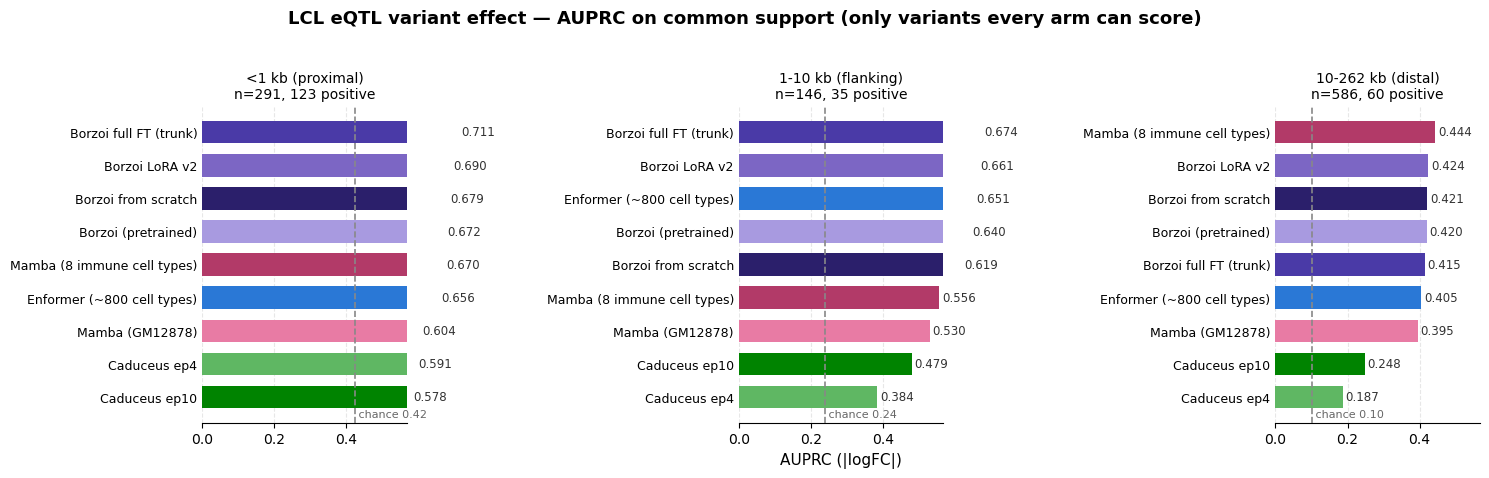


change from restricting to common support (common - all):


,<1 kb (proximal),1-10 kb (flanking),10-262 kb (distal)
Enformer (~800 cell types),0.0,0.0,0.0445
Mamba (GM12878),0.0,0.0,0.0507
Mamba (8 immune cell types),0.0,0.0,0.0636
Borzoi (pretrained),0.0,0.0,0.0626
Borzoi LoRA v2,0.0,0.0,0.0630
Borzoi full FT (trunk),0.0,0.0,0.0633
Borzoi from scratch,0.0,0.0,0.0453
Caduceus ep4,0.0,0.0,0.0599
Caduceus ep10,0.0,0.0,0.0493


In [5]:
# §5 - support accounting, then the common-support comparison.
rows = []
for a in ARMS:
    full_bins = np.load(QTL_DIR + a.fname, mmap_mode='r').shape[1]
    u = ~SCORABLE[a.key]
    rows.append({
        'arm': a.label,
        'input window (bp)': a.input_bp,
        'reach from TSS (bp)': a.input_bp // 2,
        'output span (bp)': full_bins * a.bin_bp,
        'scorable': int(SCORABLE[a.key].sum()),
        'last scored (bp)': int(distances[SCORABLE[a.key]].max()),
        'first unscored (bp)': int(distances[u].min()) if u.any() else None,
        'unscorable in distal bin': int((u & DIST_MASKS[2]).sum()),
    })
display(pd.DataFrame(rows).set_index('arm'))

lost = ~COMMON & DIST_MASKS[2]
print(f'\ncommon support: {COMMON.sum()} / {N_QTL} variants scorable by every arm')
print(f'dropped from the distal bin: {int(lost.sum())} variants '
      f'({int(labels[lost].sum())} positive, {labels[lost].mean():.1%} -- '
      f'vs {labels[DIST_MASKS[2]].mean():.1%} in the bin overall)')
print('the dropped rows are mostly negatives, so scoring them 0.0 inflates any arm that '
      'cannot see them')

AUPRC_COMMON = auprc_table('logfc', row_mask=COMMON)
plot_auprc_panels(AUPRC_COMMON,
                  'LCL eQTL variant effect — AUPRC on common support '
                  '(only variants every arm can score)',
                  row_mask=COMMON)

delta = pd.DataFrame((AUPRC_COMMON - AUPRC_ALL).T,
                     index=[a.label for a in ARMS], columns=BIN_NAMES).round(4)
print('\nchange from restricting to common support (common - all):')
display(delta)

## 6. Precision-recall curves

Pooled over all distances, on common support, so every curve is built from the same
variants. Legend is sorted by AUC.

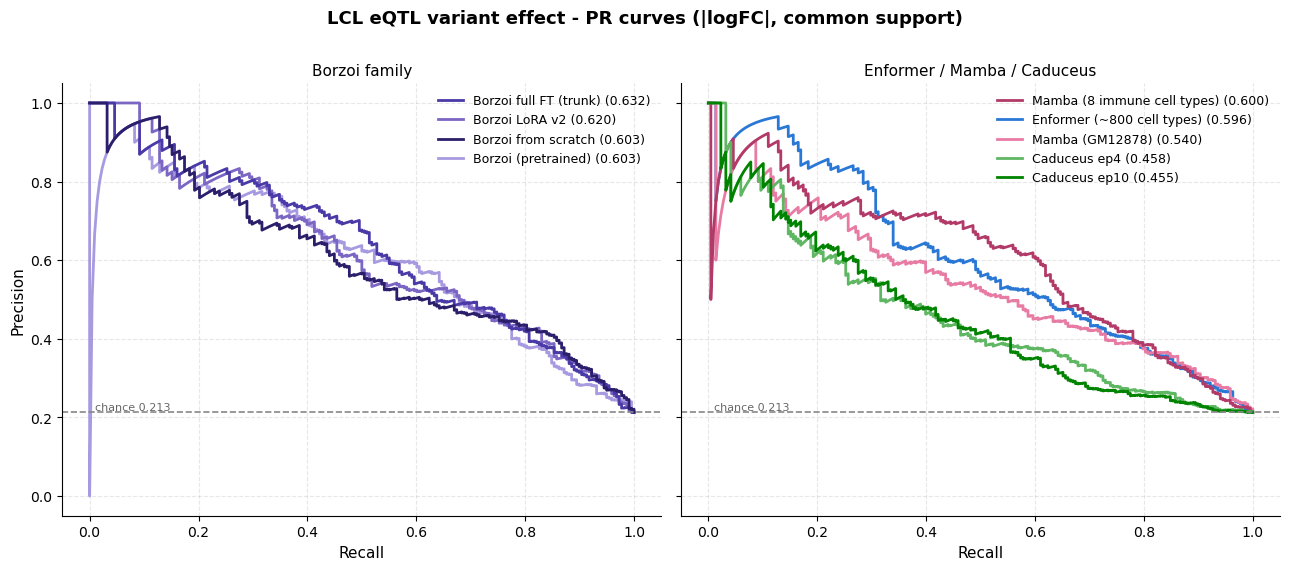

In [6]:
# §6 - PR curves on common support, all distances pooled.
# Nine overlapping curves in one panel is past what colour can carry -- the four Borzoi
# violets are a ramp, and a ramp is unreadable as overlapping lines. So: two facets, the
# question of interest on the left, everything else on the right, shared axes.
FACETS = [('Borzoi family', [a for a in ARMS if a.family == 'Borzoi']),
          ('Enformer / Mamba / Caduceus', [a for a in ARMS if a.family != 'Borzoi'])]

chance = labels[COMMON].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True, sharey=True)
for ax, (fname_, arms_) in zip(axes, FACETS):
    entries = []
    for a in arms_:
        pr, rc, _ = precision_recall_curve(labels[COMMON], SCORES[a.key]['logfc'][COMMON])
        pr_auc = auc(rc, pr)
        line, = ax.plot(rc, pr, color=a.color, lw=2, label=a.label)
        entries.append((pr_auc, line, f'{a.label} ({pr_auc:.3f})'))
    ax.axhline(chance, ls='--', lw=1.2, color='#888888')
    ax.text(0.01, chance, f'chance {chance:.3f} ', fontsize=8, color='#666666',
            ha='left', va='bottom')
    entries.sort(reverse=True, key=lambda x: x[0])
    ax.legend([e[1] for e in entries], [e[2] for e in entries], fontsize=9,
              frameon=False, loc='upper right')
    ax.set_title(fname_, fontsize=11)
    ax.set_xlabel('Recall', fontsize=11)
    ax.grid(ls='--', alpha=0.3)
    ax.set_axisbelow(True)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
axes[0].set_ylabel('Precision', fontsize=11)
fig.suptitle('LCL eQTL variant effect - PR curves (|logFC|, common support)',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

## 7. Does finetuning move Borzoi?

The panel that answers the original question, with the other families dropped for
legibility. Same numbers as §5, just isolated.

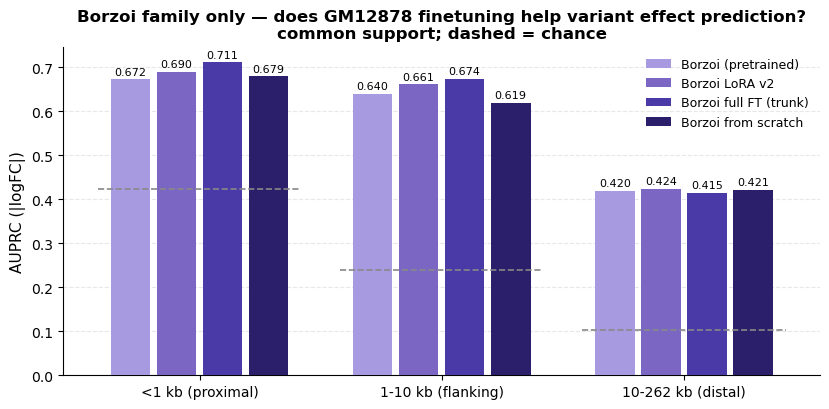

Borzoi family, common support, AUPRC:


,family,<1 kb (proximal),1-10 kb (flanking),10-262 kb (distal)
Borzoi (pretrained),Borzoi,0.6725,0.6396,0.4196
Borzoi LoRA v2,Borzoi,0.6895,0.6611,0.4240
Borzoi full FT (trunk),Borzoi,0.7109,0.6737,0.4146
Borzoi from scratch,Borzoi,0.6791,0.6188,0.4214


In [7]:
# §7 - the Borzoi family alone, on common support.
bor = [i for i, a in enumerate(ARMS) if a.family == 'Borzoi']
fig, ax = plt.subplots(figsize=(8.4, 4.2))
x = np.arange(len(BIN_NAMES))
w = 0.19
for j, i in enumerate(bor):
    ax.bar(x + (j - (len(bor) - 1) / 2) * w, AUPRC_COMMON[:, i], width=w * 0.86,
           color=ARMS[i].color, label=ARMS[i].label, zorder=3)
    for bi in range(len(BIN_NAMES)):
        ax.text(x[bi] + (j - (len(bor) - 1) / 2) * w, AUPRC_COMMON[bi, i] + 0.006,
                f'{AUPRC_COMMON[bi, i]:.3f}', ha='center', va='bottom', fontsize=8)
for bi, m in enumerate([d & COMMON for d in DIST_MASKS]):
    ax.hlines(labels[m].mean(), x[bi] - 0.42, x[bi] + 0.42,
              ls='--', lw=1.2, color='#888888', zorder=4)
ax.set_xticks(x)
ax.set_xticklabels(BIN_NAMES, fontsize=10)
ax.set_ylabel('AUPRC (|logFC|)', fontsize=11)
ax.set_title('Borzoi family only — does GM12878 finetuning help variant effect prediction?\n'
             'common support; dashed = chance', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.grid(axis='y', ls='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

print('Borzoi family, common support, AUPRC:')
display(auprc_frame(AUPRC_COMMON).iloc[bor])